## Supernova distances and redshifts (part 1):
### Tasks:

First let's fit our supernova synthetic data from last time using GPR.

- The key ingredient in getting a good GPR fit is the choice of the kernel and its parameters.
- Check out what's available in the kernels submodule of sklearn.gaussian_process
- Hint. Radial-basis function kernel (aka squared-exponential kernel) is a standard choice in the GPR world.
- Plot the expectation value of the fit as well as the resulting 1-sigma and 2-sigma contours.
- Interpret the results.

In [1]:
from sklearn.linear_model import RidgeCV
import matplotlib.pyplot as plt
import numpy as np

(35.0, 50.0)

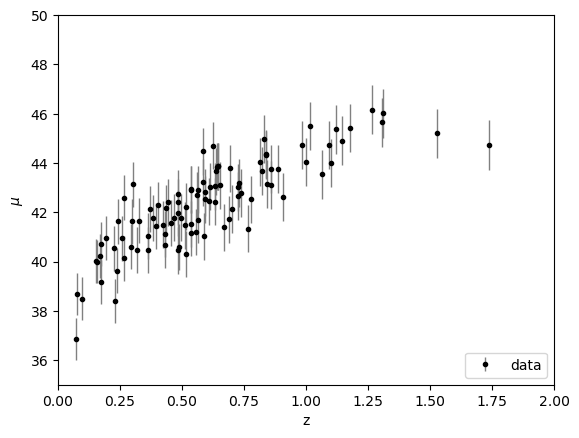

In [2]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

In [3]:
from sklearn.gaussian_process import GaussianProcessRegressor, kernels

kernel = kernels.RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + kernels.WhiteKernel(noise_level=1.0)
GPR = GaussianProcessRegressor(kernel=kernel, alpha=dmu**2, normalize_y=True)
GPR.fit(z_sample[:, None], mu_sample)

X = np.linspace(0, 2, 1000)[:, None]
y, std = GPR.predict(X, return_std = True)

print(GPR.kernel_)

RBF(length_scale=0.683) + WhiteKernel(noise_level=1e-05)


/opt/anaconda3/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


(35.0, 50.0)

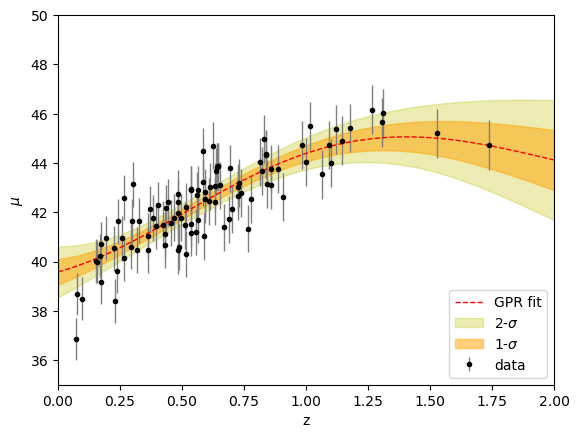

In [4]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(X[:,0], y, '--r', lw = 1, label='GPR fit')
plt.fill_between(X[:,0], y-2*std, y+2*std, alpha = 0.3, color = 'y', label = r'2-$\sigma$')
plt.fill_between(X[:,0], y-std, y+std, alpha = 0.5, color = 'orange', label = r'1-$\sigma$')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

Not bad! Clearly our alogrithm does better where we have much more points, while where there's just few points present, the sigma is much bigger as we have less information about our model. 
Nevertheless, we got a much better result than with a polynomial fit !

In [5]:
#Let's try some CV!
from sklearn.model_selection import GridSearchCV
kernel = kernels.RBF() + kernels.WhiteKernel(noise_level_bounds=(1e-8, 1e1))
GPR = GaussianProcessRegressor(kernel=kernel, alpha=np.mean(dmu)**2, normalize_y=True)
param_grid = {'kernel__k1__length_scale': np.linspace(0.1, 5, 10),
              'kernel__k2__noise_level': np.linspace(1e-8, 1, 20) }
K = 5

gridCV = GridSearchCV(GPR, param_grid=param_grid, cv = K)
gridCV.fit(z_sample[:,None], mu_sample)

print("Best parameters:", gridCV.best_params_)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:420: Con

Best parameters: {'kernel__k1__length_scale': 3.366666666666667, 'kernel__k2__noise_level': 0.5263157942105263}


In [6]:
opt_ls = gridCV.best_params_['kernel__k1__length_scale']
opt_nl = gridCV.best_params_['kernel__k2__noise_level']
best_kernel = kernels.RBF(length_scale=opt_ls) + kernels.WhiteKernel(noise_level=opt_nl, noise_level_bounds=(1e-8, 1e1))
best_GPR = GaussianProcessRegressor(kernel=best_kernel, alpha=np.mean(dmu)**2, normalize_y=True)

from sklearn.model_selection import train_test_split
z_train, z_test, mu_train, mu_test, dmu_train, dmu_test = train_test_split(z_sample, mu_sample, dmu, train_size=0.8, test_size=0.2)

best_GPR.fit(z_train[:,None], mu_train)
y_pred, sigma = best_GPR.predict(X, return_std=True)
mu_pred, std_mu = best_GPR.predict(z_test[:,None], return_std=True)

(35.0, 50.0)

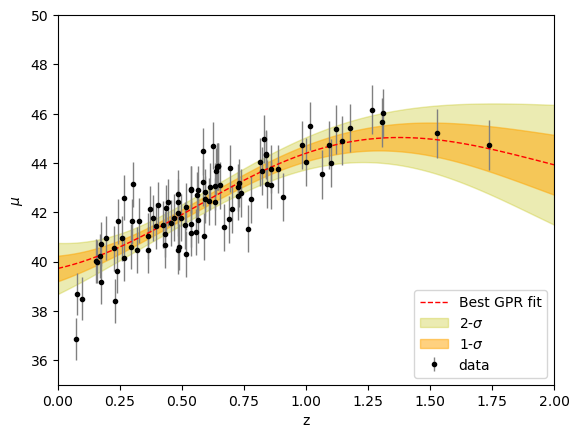

In [7]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(X[:,0], y_pred, '--r', lw = 1, label='Best GPR fit')
plt.fill_between(X[:,0], y_pred-2*std, y_pred+2*std, alpha = 0.3, color = 'y', label = r'2-$\sigma$')
plt.fill_between(X[:,0], y_pred-std, y_pred+std, alpha = 0.5, color = 'orange', label = r'1-$\sigma$')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

(35.0, 50.0)

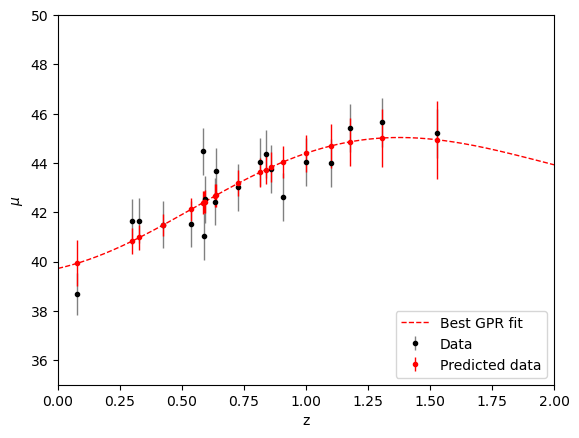

In [8]:
plt.plot(X[:,0], y_pred, '--r', lw = 1, label='Best GPR fit')
plt.errorbar(z_test, mu_test, dmu_test, fmt='.k', ecolor='gray', lw=1,label='Data')
plt.errorbar(z_test, mu_pred, 2*std_mu, fmt='.r', ecolor='red', lw=1,label='Predicted data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

#### Parametric Fitting with emcee:

We now have a suite of **data-driven** predictive models for our supernova dataset (from polynomials to GPR). That is: we can faithfully predict how a future redshift/distance measurement will look like given the current sample.

This is already great and these kind of tools are immensely useful in a variety of contexts (also involving a lot of money: suppose you want to predict how much a give financial asset will perform on tomorrow's stock market... You  might not really care about expressing the underlying financial model in simple terms, as long as your investments are profitable).

For the case of supernovae, however, we have do have physical theory which is $\Lambda$CDM. We can do a **parametric** fit (and hopehully by now the difference between "parametric" and "data driven" fit is clear in your head)

- First, refresh your cosmology and write down the predicted relationship between the distance module $\mu$ and the redshift $\sigma$. *Hint* I always forget these things, my to-go reference is [Hogg (2010)](https://arxiv.org/abs/astro-ph/9905116). I got:

$$\mu = 5 \log \left( \frac{c/H_0} {10 {\rm pc}}(1+z)\int_0^z \frac{dz'}{\sqrt{\Omega_m (1+z^3)+\Omega_\Lambda}} \right) $$


- Assuming a flat Universe,  we have a parametric non-linear model for $\mu(z)$ that depends on two parameters, the Hubble constant $H_0$ and the matter content of the Universe $\Omega_m$
- It's a very non-linear model. Fit it to the data (however you want to do it, are you frequentist or Bayesian after all?).
- What are the measured value of $H_0$ and $\Omega_m$. Are they correlated?
- How would a model without dark energy (i.e. $\Omega_m=1$) perform? Do these data contain evidence of dark energy? (Hint: this is a model selection problem!)

In [10]:
from scipy.constants import c
import scipy
c_km = c / 1000

def f(z, OmegaM):
    return 1/np.sqrt(OmegaM*(1+z)**3+(1-OmegaM))
    
def mu(theta, z):
    H0, OmegaM = theta
    I = np.array([scipy.integrate.quad(lambda i: f(i, OmegaM), 0, i)[0] for i in z]) 
    return 5*np.log10(((c_km/H0)/1e-5)*(1+z)*I)

In [11]:
theta_test = np.array([73, 0.3])
mu_model = mu(theta_test, X[:,0])

/var/folders/t8/13zffs7d1wd77m4d5nxdd7540000gn/T/ipykernel_81911/3322462881.py:11: RuntimeWarning: divide by zero encountered in log10
  return 5*np.log10(((c_km/H0)/1e-5)*(1+z)*I)


(35.0, 50.0)

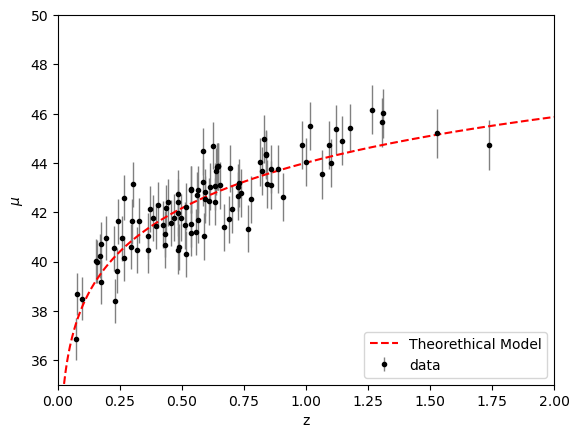

In [15]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(X[:,0], mu_model, '--r', label = 'Theorethical Model')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc = 'lower right')
plt.xlim(0,2)
plt.ylim(35,50)

In [16]:
def log_likelihood(theta, z, mu_obs, mu_err):
    mu_model = mu(theta, z)
    return -0.5 * np.sum(((mu_obs - mu_model) / mu_err)**2 + np.log(2 * np.pi * mu_err**2))

#Using flat priors:
def log_prior(theta):
    H0, OmegaM = theta
    if 40 < H0 < 80 and 0.0 < OmegaM < 1.0:
        return 0.0 
    return -np.inf

def log_posterior(theta, z, mu_obs, mu_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mu_obs, mu_err)

In [17]:
import emcee

ndim = 2
nwalkers = 32  
nsteps = 5000  

starting_guesses = theta_test + 0.01 * np.random.randn(nwalkers, ndim)


sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[z_sample, mu_sample, dmu])
sampler.run_mcmc(starting_guesses, nsteps, progress=True)
 
emcee_trace  = sampler.chain.reshape(-1, ndim)

100%|██████████| 5000/5000 [12:51<00:00,  6.48it/s]


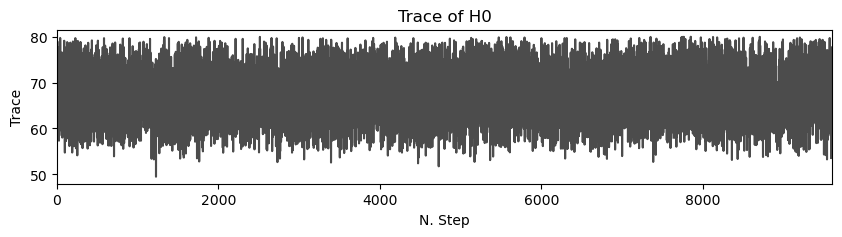

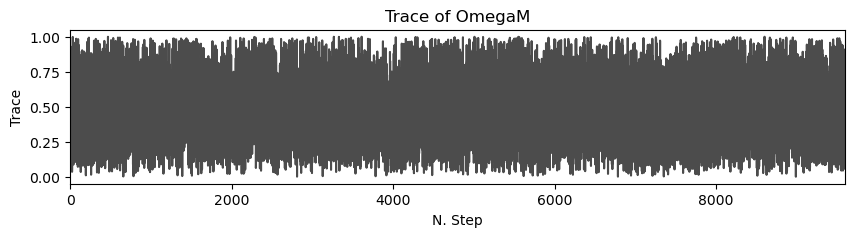

In [18]:
emcee_trace = sampler.get_chain(discard=500, thin=15, flat=True)
size = len(emcee_trace[:,0])

x_trace = np.linspace(1, size, size)
labels = ['H0', 'OmegaM']
for i in range(len(theta_test)):
   plt.figure(figsize = (10, 2))
   plt.plot(x_trace, emcee_trace[:, i], label = labels[i], alpha = 0.7, color = 'k')
   plt.title(f'Trace of {labels[i]}')
   plt.ylabel('Trace')
   plt.xlabel('N. Step')
   plt.xlim(0, size)

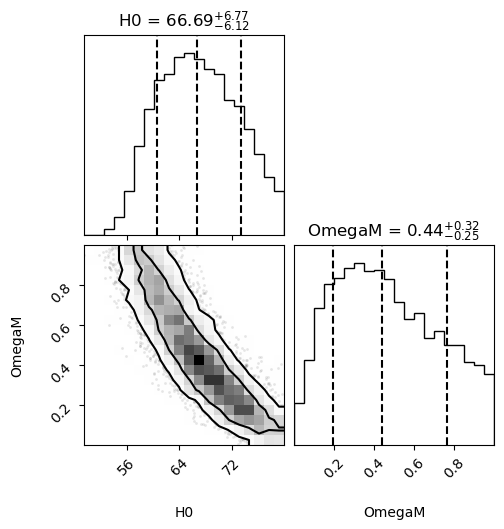

In [19]:
import corner
fig = corner.corner(
    emcee_trace, labels=labels, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], show_titles=True);

The 2 parameters are correlated and our 68% confidence interval includes the expected valued $H_0 = 67 km/s/Mpc$ e $\Omega_M = 0.3$ ! 


- How would a model without dark energy (i.e. OmegaM = 1) perform? Do these data contain evidence of dark energy? (Hint: this is a model selection problem!)

In [20]:
#Using dynesty for model selection and param estimation!
import dynesty 
from scipy import stats

In [21]:

########################## W/ DE: ##########################

def log_likelihood_DE(theta, z, mu_obs, mu_err):
    mu_model = mu(theta, z)
    return -0.5 * np.sum(((mu_obs - mu_model) / mu_err)**2 + np.log(2 * np.pi * mu_err**2))
    
#Using the priors in the limit [0,1] for dynesty 
def prior_DE(theta):
    priors = np.copy(theta)
    priors[0] = stats.uniform.ppf(theta[0], loc = 40, scale = 40)
    priors[1] = stats.uniform.ppf(theta[1], loc = 0.0, scale =1)
    return priors


########################## W/ NO DE ##########################
def f_noDE(z):
    return 1/np.sqrt((1+z)**3)

def mu_noDE(theta, z):
    H0 = theta
    I = np.array([scipy.integrate.quad(lambda i: f_noDE(i), 0, i)[0] for i in z]) 
    return 5*np.log10(((c_km/H0)/1e-5)*(1+z)*I)

def log_likelihood_noDE(theta, z, mu_obs, mu_err):
    mu_model = mu_noDE(theta, z)
    return -0.5 * np.sum(((mu_obs - mu_model) / mu_err)**2 + np.log(2 * np.pi * mu_err**2))
    
#Using the priors in the limit [0,1] for dynesty 
def prior_noDE(theta):
    H0 = theta
    prior = stats.uniform.ppf(H0, loc = 1 , scale = 90)
    return prior

/var/folders/t8/13zffs7d1wd77m4d5nxdd7540000gn/T/ipykernel_81911/3275155051.py:22: RuntimeWarning: divide by zero encountered in log10
  return 5*np.log10(((c_km/H0)/1e-5)*(1+z)*I)


(35.0, 50.0)

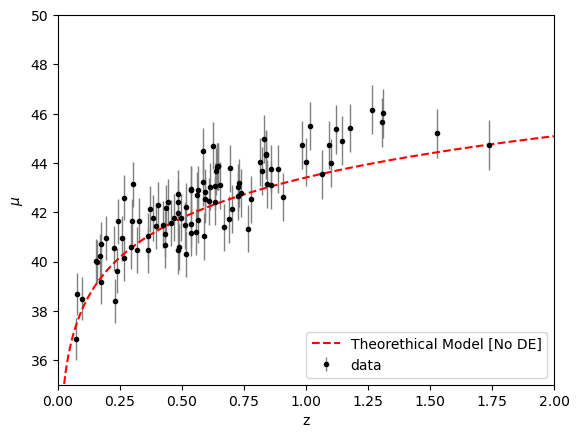

In [22]:
mu_model = mu_noDE(73, X[:,0])

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(X[:,0], mu_model, '--r', label = 'Theorethical Model [No DE]')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc = 'lower right')
plt.xlim(0,2)
plt.ylim(35,50)

In [23]:
ndimDE = 2
ndimnoDE = 1

sampler = dynesty.NestedSampler(log_likelihood_DE, prior_DE, ndimDE, logl_args = [z_sample, mu_sample, dmu], nlive = 300)
sampler.run_nested()
sresults = sampler.results

973it [00:58, 16.69it/s, +300 | bound: 0 | nc: 1 | ncall: 8917 | eff(%): 14.773 | loglstar:   -inf < -132.813 <    inf | logz: -134.753 +/-  0.053 | dlogz:  0.001 >  0.309]


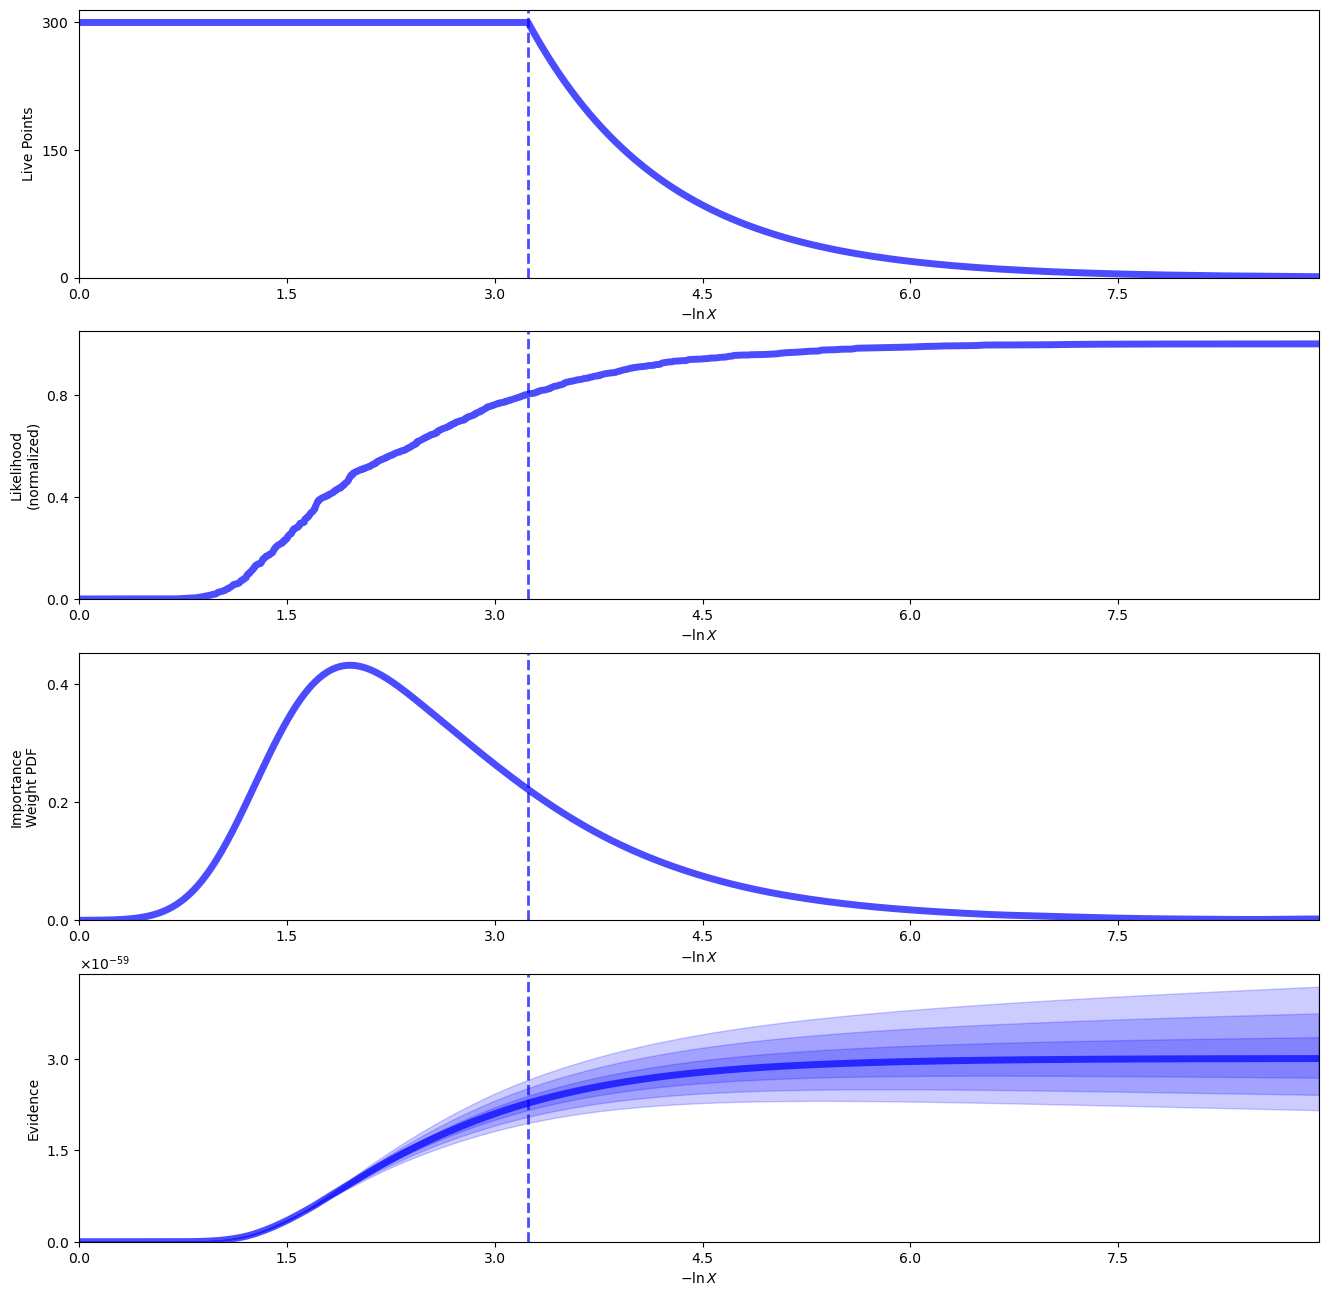

In [24]:
from dynesty import plotting as dyplot

rfig, raxes = dyplot.runplot(sresults)

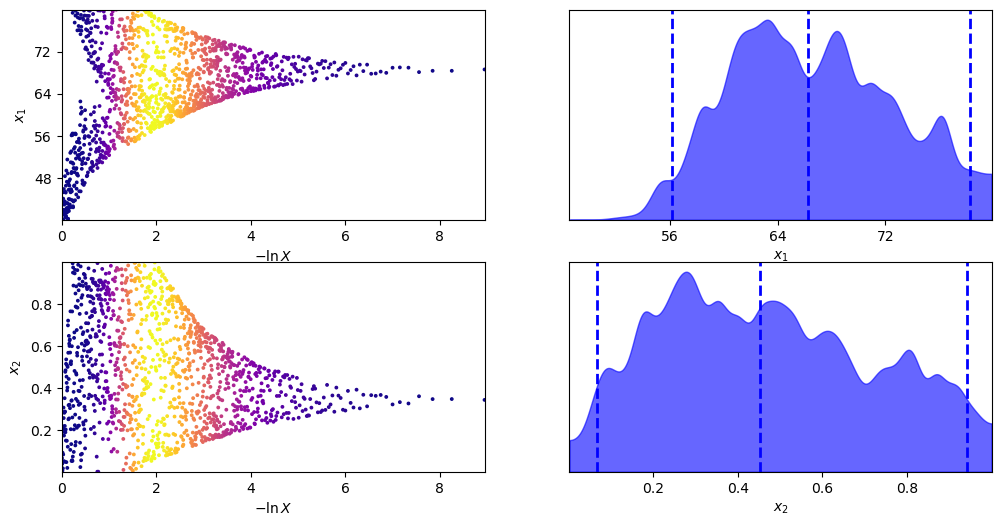

In [25]:
tfig, taxes = dyplot.traceplot(sresults)

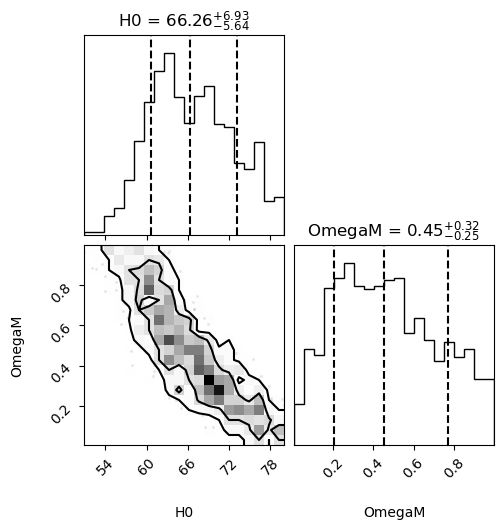

In [26]:
from dynesty import utils as dyfunc

samples = sresults.samples 
weights = np.exp(sresults.logwt - sresults.logz[-1])
labels = ['H0', 'OmegaM']

DE_evidence = np.exp(sresults.logz[-1])

samples_noweight = dyfunc.resample_equal(samples, weights)
corner.corner(samples_noweight, labels=labels, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], show_titles=True);

best_params = np.array([np.mean(samples_noweight[:,i]) for i in range(ndimDE)])

In [27]:
sampler = dynesty.NestedSampler(log_likelihood_noDE, prior_noDE, ndimnoDE, logl_args = [z_sample, mu_sample, dmu], nlive = 300)
sampler.run_nested()
sresults_noDE = sampler.results

1184it [00:50, 23.29it/s, +300 | bound: 1 | nc: 1 | ncall: 11095 | eff(%): 13.747 | loglstar:   -inf < -133.530 <    inf | logz: -136.150 +/-  0.071 | dlogz:  0.001 >  0.309]


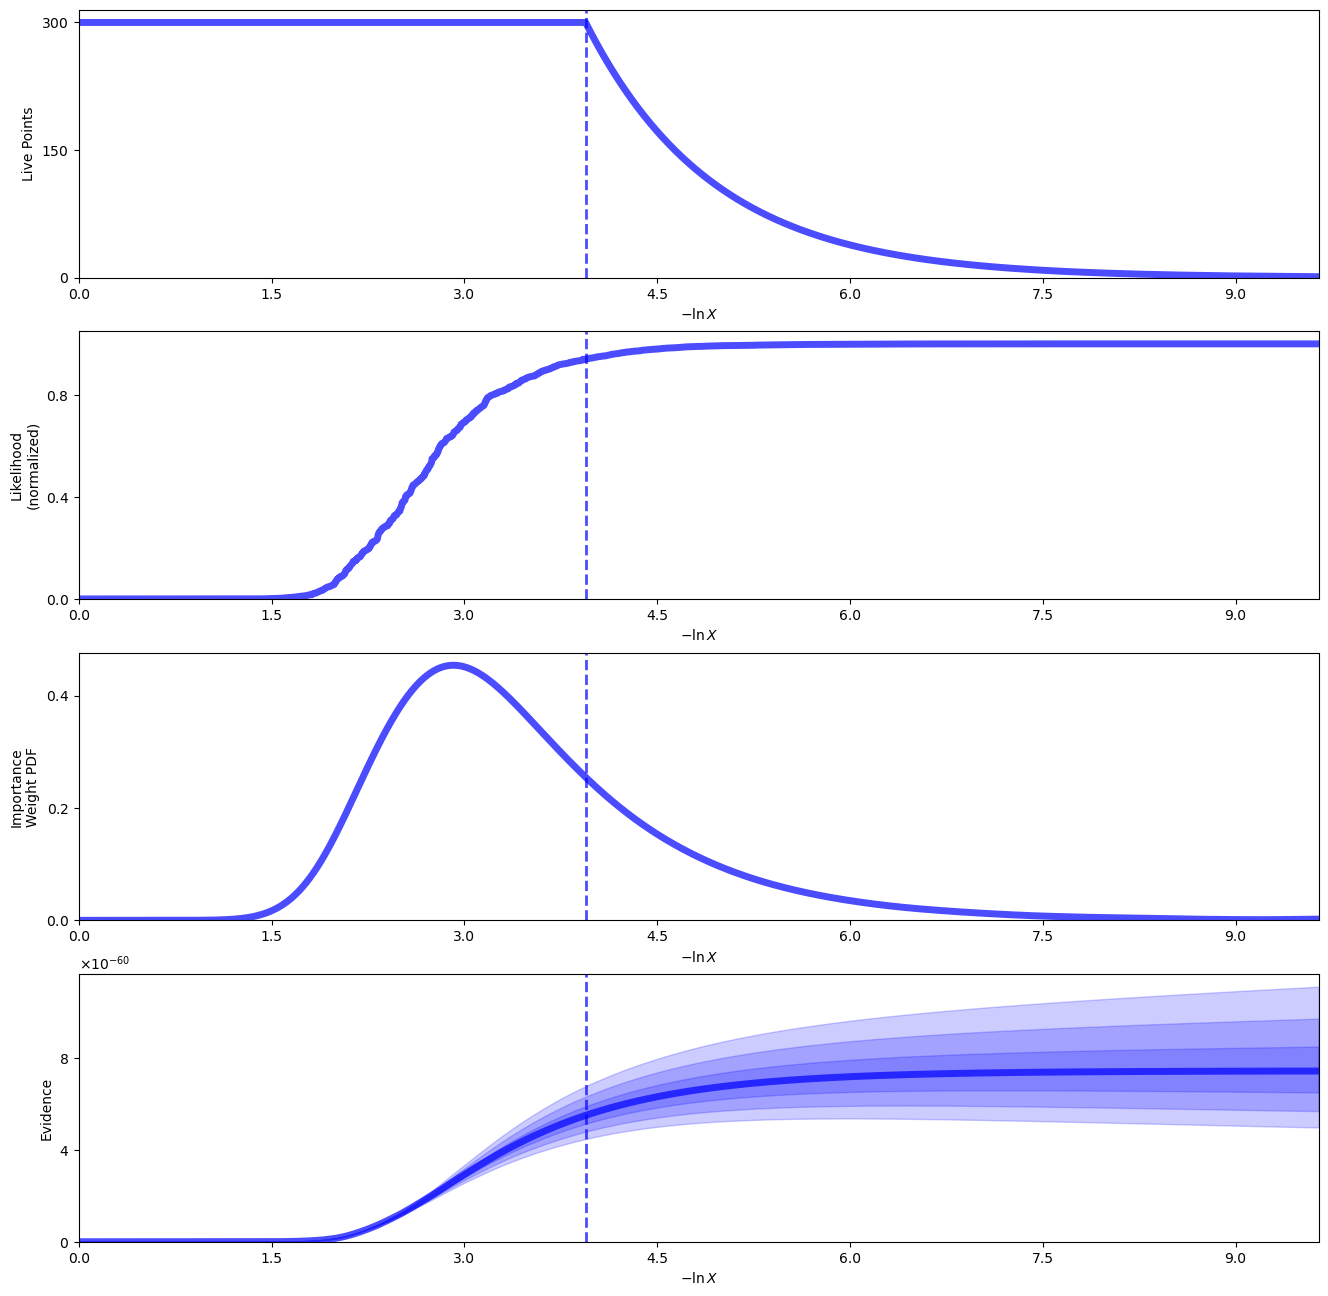

In [28]:
rfig, raxes = dyplot.runplot(sresults_noDE)

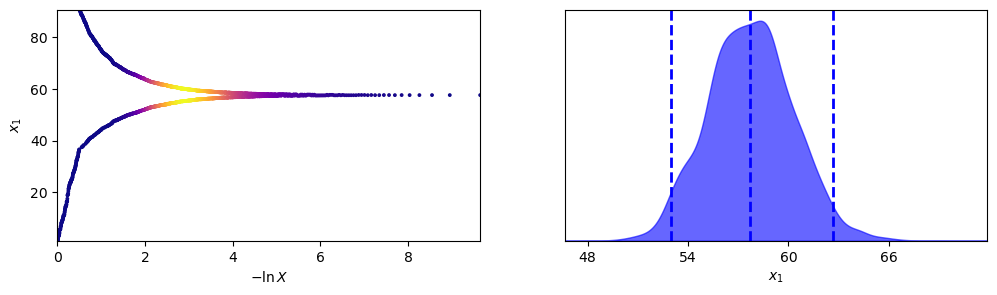

In [29]:
tfig, taxes = dyplot.traceplot(sresults_noDE)

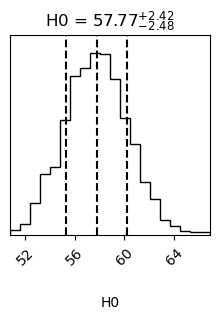

In [30]:
samples_noDE = sresults_noDE.samples 
weights = np.exp(sresults_noDE.logwt - sresults_noDE.logz[-1])
labels = ['H0']

noDE_evidence = np.exp(sresults_noDE.logz[-1])

samples_noweight = dyfunc.resample_equal(samples_noDE, weights)
corner.corner(samples_noweight, labels=labels, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], show_titles=True);

best_thetsab = np.array([np.mean(samples_noweight[:,i]) for i in range(ndimnoDE)])

In [31]:
odds_ratio = DE_evidence/noDE_evidence
print(odds_ratio)

4.044201461437684


According to Jeffreys scale, there's Substantial evidence for our DE model !

### Cloning data:

The European Space Agency is considering new cosmology-related space mission. They ask you to figure out what science you can do with 10 times more measurement compared to what you have right now. That is: you want to clone your data. We've seen this earlier in the class, but now we can do much much better.
- Think about the pdf of these data in $z$.
- Using both the GPR fit and your latest $\Lambda$CDM fit, generate a set of $\mu$ measurements that respects the statistical properties of the data you were given. 

In [32]:
new_size = 10*len(z_sample)

from sklearn.neighbors import KernelDensity
kde = KernelDensity(kernel='gaussian', bandwidth=0.3).fit(z_sample[:,None]) 
#using a large bw to have data almost 'everywhere', but still using how our measurment in z were distributed. 
X = kde.sample(new_size)

# Using the GPR fit:
new_y = best_GPR.predict(X)

sigma_sim = np.random.choice(dmu, size=new_size)
noise = np.random.normal(0, sigma_sim)
mu_sim = new_y + noise

(35.0, 50.0)

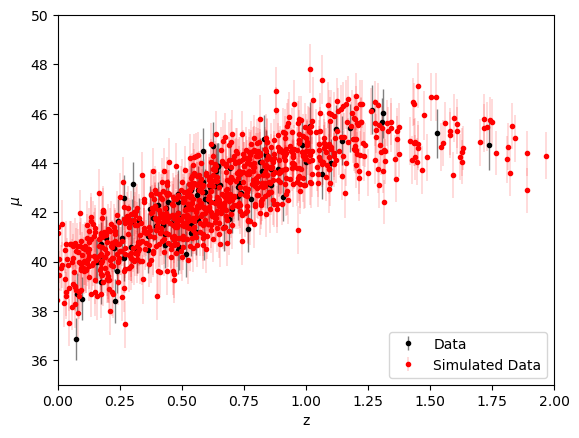

In [33]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='Data')
plt.errorbar(X, mu_sim, sigma_sim,  fmt='.r', ecolor='red', lw=0.2,label='Simulated Data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

In [34]:
#Using our Lambda-CDM model 
X = kde.sample(new_size)
y_LCDM = mu(best_params, X[:,0])
sigma_sim_LCDM = np.random.choice(dmu, size=new_size)
noise_LCDM = np.random.normal(0, sigma_sim_LCDM)
mu_sim_LCDM = y_LCDM + noise_LCDM

/var/folders/t8/13zffs7d1wd77m4d5nxdd7540000gn/T/ipykernel_81911/3322462881.py:11: RuntimeWarning: invalid value encountered in log10
  return 5*np.log10(((c_km/H0)/1e-5)*(1+z)*I)


(35.0, 50.0)

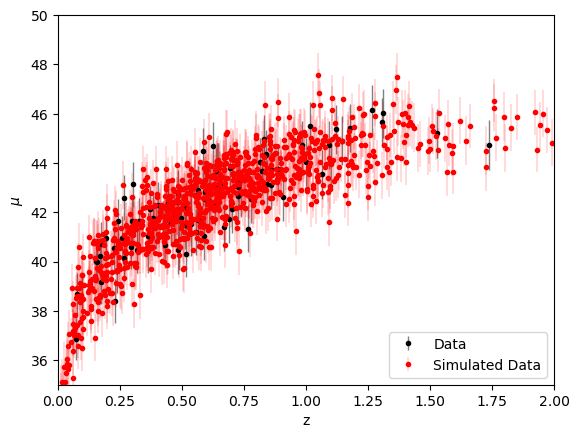

In [35]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='Data')
plt.errorbar(X, mu_sim_LCDM, sigma_sim_LCDM,  fmt='.r', ecolor='red', lw=0.2,label='Simulated Data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)